# 🇮🇹 Analisi del carico del sistema giudiziario italiano (2003–2024)

Questo notebook utilizza il dataset **"Italy Justice System Workload (2003–2024)"**, che raccoglie una serie storica nazionale sui procedimenti civili e penali pendenti in Italia.

I dati provengono da fonti ufficiali:

- Ministero della Giustizia – statistiche sui procedimenti civili e penali
- ISTAT – popolazione residente

Il dataset è composto da tre file principali:

- **civile.csv**  
  Procedimenti civili pendenti suddivisi per livello di giudizio (Cassazione, Corte d’Appello, Tribunale ordinario, Tribunale per i minorenni, Giudice di Pace).

- **penale.csv**  
  Procedimenti penali pendenti suddivisi per livello di giudizio, con totali calcolati sia **includendo** sia **escludendo** i procedimenti del Giudice di Pace.

- **indicatori.csv**  
  Indicatori derivati che descrivono la pressione del sistema giudiziario sulla popolazione e la struttura del contenzioso.

Gli indicatori principali sono:

- **pressione civile**  
  numero di procedimenti civili pendenti ogni 100.000 abitanti

- **pressione penale**  
  numero di procedimenti penali pendenti ogni 100.000 abitanti

- **conflittualità**  
  quota del contenzioso civile ordinario sul totale dei procedimenti civili

- **crisi economica**  
  quota delle procedure esecutive e concorsuali sul totale del contenzioso civile

- **micro-illegalità**  
  peso dei procedimenti penali trattati dal Giudice di Pace sul totale dei procedimenti penali

## Obiettivo del notebook

In questo notebook analizzeremo:

- l'evoluzione del carico del sistema giudiziario italiano dal **2003 al 2024**
- le differenze tra **procedimenti civili e penali**
- i cambiamenti strutturali nel contenzioso
- l'andamento degli indicatori nel tempo

L'obiettivo è comprendere come il sistema giudiziario italiano sia cambiato negli ultimi vent’anni e quali dinamiche emergono dai dati.

In [1]:
# Questo ambiente Python è fornito da Kaggle e contiene già le principali librerie
# per l'analisi dei dati (pandas, numpy, matplotlib, ecc.).
import pandas as pd
import matplotlib.pyplot as plt
import os

# Importiamo la funzione display per visualizzare le tabelle in formato tabellare pulito nel notebook
from IPython.display import display

# Disabilita i warning di formattazione numerica generati automaticamente da pandas
# per mantenere l’output pulito e focalizzato sui contenuti del dataset.
import warnings
warnings.filterwarnings("ignore")

# Visualizziamo tutti i file disponibili nella cartella di input del notebook.
# Questo permette a chi legge di capire quali dataset sono caricati nel progetto.
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/indicatori.csv
/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/civile.csv
/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/penale.csv


In [2]:
# Caricamento dei fogli
civile = pd.read_csv('/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/civile.csv')
penale = pd.read_csv('/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/penale.csv')
indicatori = pd.read_csv('/kaggle/input/datasets/lucalullo/italy-justice-system-workload-2003-2024/indicatori.csv')

In [3]:
# Visualizzazione foglio civile
display(civile.head())
civile.info()

,anno,cassazione,corte_appello,tribunale_ordinario,tribunale_minorenni,giudice_pace,pendenti_totali_nazionali,area_siecic,area_sicid,variazione_vs_anno_precedente,variazione_area_siecic,variazione_area_sicid
0,2003,91963,253429,3363937,110477,777674,4597480,743240,3854240,NaN,NaN,NaN
1,2004,93726,289608,3307625,109100,948556,4748615,722539,4026076,0.033,-0.028,0.045
2,2005,95081,323916,3307007,112057,1023454,4861515,700907,4160608,0.024,-0.030,0.033
3,2006,100805,359011,3326263,119886,1190885,5096850,675517,4421333,0.048,-0.036,0.063
4,2007,102588,376519,3318876,124906,1371672,5294561,650229,4644332,0.039,-0.037,0.050


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   anno                           22 non-null     int64  
 1   cassazione                     22 non-null     int64  
 2   corte_appello                  22 non-null     int64  
 3   tribunale_ordinario            22 non-null     int64  
 4   tribunale_minorenni            22 non-null     int64  
 5   giudice_pace                   22 non-null     int64  
 6   pendenti_totali_nazionali      22 non-null     int64  
 7   area_siecic                    22 non-null     int64  
 8   area_sicid                     22 non-null     int64  
 9   variazione_vs_anno_precedente  21 non-null     float64
 10  variazione_area_siecic         21 non-null     float64
 11  variazione_area_sicid          21 non-null     float64
dtypes: float64(3), int64(9)
memory usage: 2.2 KB


In [4]:
# Visualizzazione foglio penale
display(penale.head())
penale.info()

,anno,cassazione,corte_appello,tribunale_ordinario,tribunale_minorenni,pendenti_totali_nazionali_escluso_giudice_pace,variazione_vs_anno_precedente_escluso_giudice_pace,giudice_pace,pendenti_totali_nazionali_incluso_giudice_pace,variazione_vs_anno_precedente_incluso_giudice_pace
0,2003,31140,130395,1139953,36061,1337549,NaN,60379,1397928,NaN
1,2004,30953,135322,1184940,39847,1391062,0.040,76113,1467175,0.050
2,2005,32862,140822,1165732,38671,1378087,-0.009,81208,1459295,-0.005
3,2006,37439,154844,1194511,40407,1427201,0.036,105987,1533188,0.051
4,2007,33177,157996,1195646,38568,1425387,-0.001,116857,1542244,0.006


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   anno                                                22 non-null     int64  
 1   cassazione                                          22 non-null     int64  
 2   corte_appello                                       22 non-null     int64  
 3   tribunale_ordinario                                 22 non-null     int64  
 4   tribunale_minorenni                                 22 non-null     int64  
 5   pendenti_totali_nazionali_escluso_giudice_pace      22 non-null     int64  
 6   variazione_vs_anno_precedente_escluso_giudice_pace  21 non-null     float64
 7   giudice_pace                                        22 non-null     int64  
 8   pendenti_totali_nazionali_incluso_giudice_pace      22 non-null     int64  
 9   v

In [5]:
# Visualizzazione foglio indicatori
display(indicatori.head())
indicatori.info()

,anno,popolazione,pressione_civile,pressione_penale,conflittualità,crisi_economica,micro_illegalita
0,2003,57186378,8039.47,2444.51,0.84,0.16,0.04
1,2004,57611990,8242.41,2546.65,0.85,0.15,0.05
2,2005,58044368,8375.52,2514.10,0.86,0.14,0.06
3,2006,58288996,8744.10,2630.32,0.87,0.13,0.07
4,2007,58510725,9048.87,2635.83,0.88,0.12,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   anno              22 non-null     int64  
 1   popolazione       22 non-null     int64  
 2   pressione_civile  22 non-null     float64
 3   pressione_penale  22 non-null     float64
 4   conflittualità    22 non-null     float64
 5   crisi_economica   22 non-null     float64
 6   micro_illegalita  22 non-null     float64
dtypes: float64(5), int64(2)
memory usage: 1.3 KB


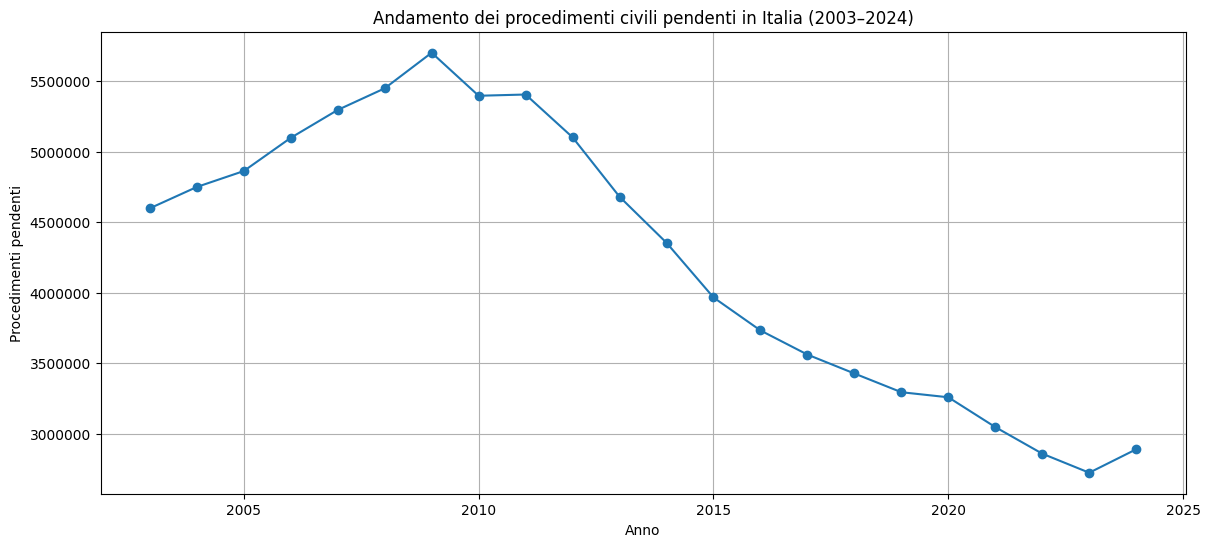

In [6]:
# Grafico dell'andamento dei procedimenti civili pendenti nel tempo
plt.figure(figsize=(14,6))

# Disegniamo una linea che mostra il numero totale di procedimenti civili per anno
plt.plot(civile["anno"], civile["pendenti_totali_nazionali"], marker="o")

# Titolo e etichette degli assi
plt.title("Andamento dei procedimenti civili pendenti in Italia (2003–2024)")
plt.xlabel("Anno")
plt.ylabel("Procedimenti pendenti")

# Disattiva la notazione scientifica sull'asse Y (rimuove il 1e6)
plt.ticklabel_format(style='plain', axis='y')

# Griglia per migliorare la leggibilità
plt.grid(True)

plt.show()

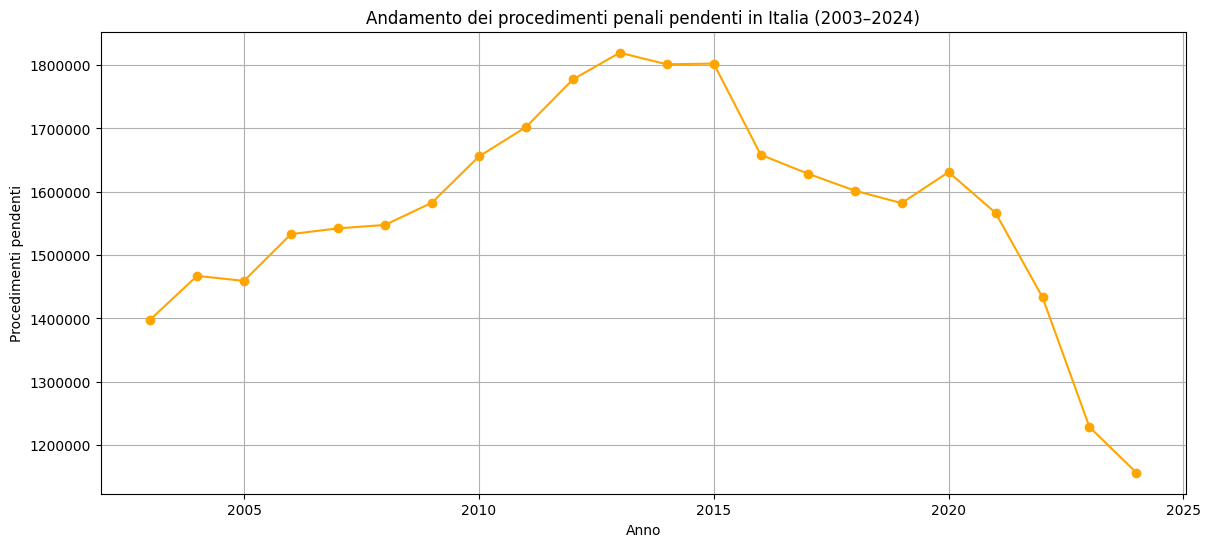

In [7]:
# Grafico dell'andamento dei procedimenti penali pendenti nel tempo
plt.figure(figsize=(14,6))

plt.plot(
    penale["anno"],
    penale["pendenti_totali_nazionali_incluso_giudice_pace"],
    marker="o",
    color="orange"
)

# Titolo e etichette degli assi
plt.title("Andamento dei procedimenti penali pendenti in Italia (2003–2024)")
plt.xlabel("Anno")
plt.ylabel("Procedimenti pendenti")

# Disattiva la notazione scientifica sull'asse Y
plt.ticklabel_format(style='plain', axis='y')

# Griglia per migliorare la leggibilità
plt.grid(True)

plt.show()

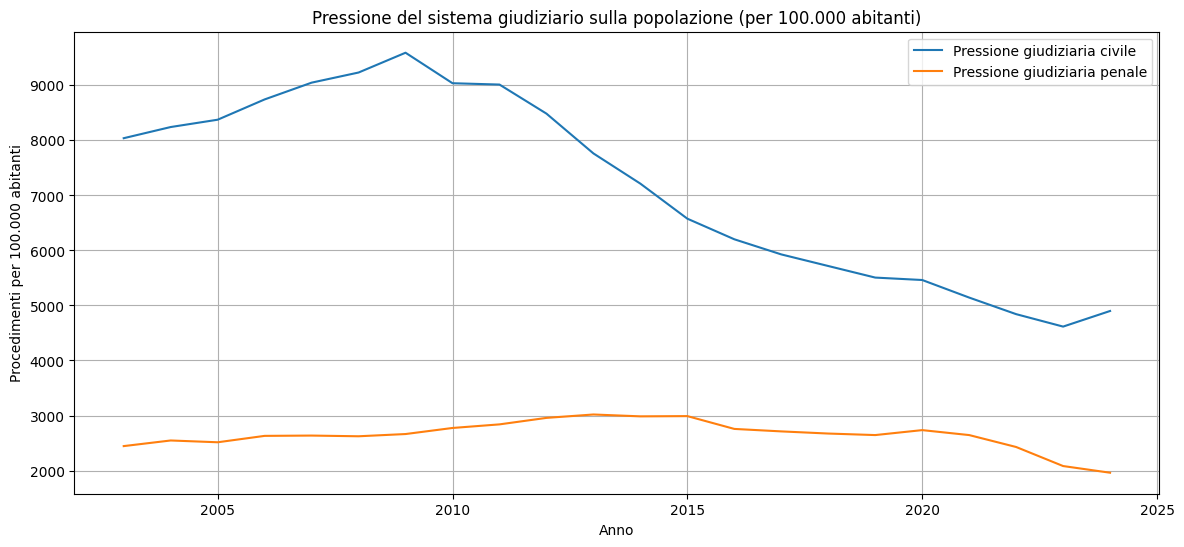

In [8]:
# Confronto tra pressione civile e pressione penale
plt.figure(figsize=(14,6))

plt.plot(indicatori["anno"], indicatori["pressione_civile"], label="Pressione giudiziaria civile")
plt.plot(indicatori["anno"], indicatori["pressione_penale"], label="Pressione giudiziaria penale")

plt.title("Pressione del sistema giudiziario sulla popolazione (per 100.000 abitanti)")
plt.xlabel("Anno")
plt.ylabel("Procedimenti per 100.000 abitanti")

plt.legend()
plt.grid(True)

plt.show()

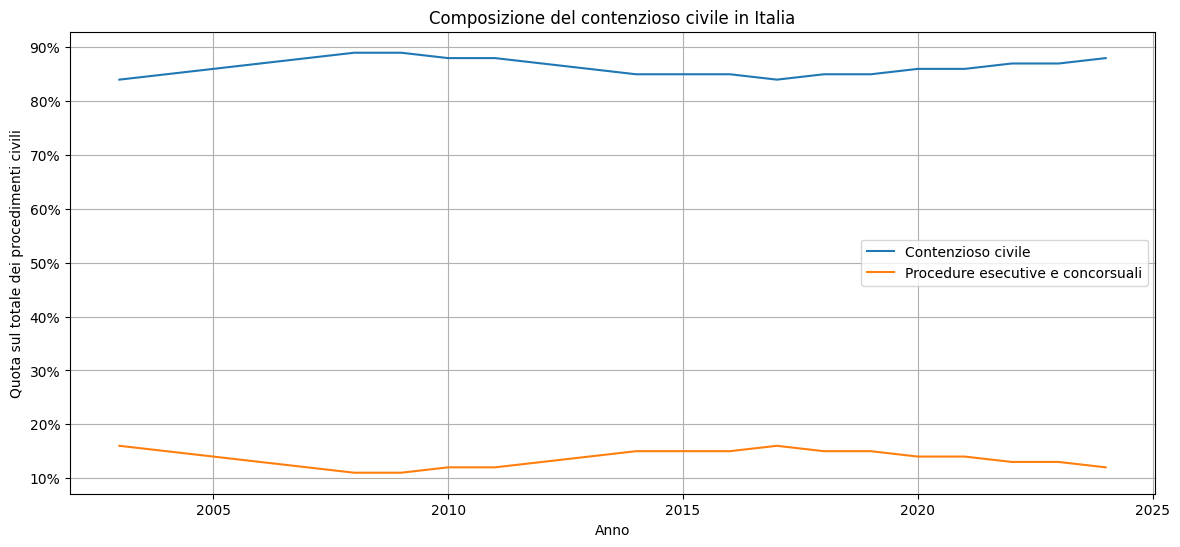

In [9]:
import matplotlib.ticker as mtick

# Analisi della composizione del contenzioso civile
plt.figure(figsize=(14,6))

plt.plot(indicatori["anno"], indicatori["conflittualità"], label="Contenzioso civile")
plt.plot(indicatori["anno"], indicatori["crisi_economica"], label="Procedure esecutive e concorsuali")

plt.title("Composizione del contenzioso civile in Italia")
plt.xlabel("Anno")
plt.ylabel("Quota sul totale dei procedimenti civili")

# Mostra l'asse Y in percentuale invece che in valori decimali
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.legend()
plt.grid(True)

plt.show()

## Osservazioni sui trend del sistema giudiziario (2003–2024)

L’analisi delle serie storiche mostra alcune tendenze rilevanti nel periodo osservato.

### Procedimenti civili pendenti
Il numero totale di procedimenti civili pendenti cresce progressivamente fino alla fine degli anni 2000, raggiungendo il valore massimo intorno al 2009. Negli anni successivi si osserva una riduzione continua del carico civile, con una lieve risalita nell’ultimo anno della serie.

### Procedimenti penali pendenti
I procedimenti penali pendenti mostrano una crescita graduale fino alla metà degli anni 2010. Successivamente il numero totale diminuisce progressivamente, con una riduzione particolarmente marcata negli ultimi anni della serie.

### Pressione giudiziaria sulla popolazione
Gli indicatori di pressione giudiziaria mostrano un livello più elevato per il contenzioso civile rispetto a quello penale lungo tutto il periodo osservato. Entrambi gli indicatori presentano una diminuzione nel tempo, soprattutto dopo la metà degli anni 2010.

### Struttura del contenzioso civile
La composizione del contenzioso civile rimane relativamente stabile nel tempo.  
La quota di procedimenti di contenzioso ordinario (SICID) rappresenta la parte prevalente del totale, mentre le procedure esecutive e concorsuali (SIECIC) costituiscono una frazione più contenuta ma costante della serie storica.

---

I dati presentati permettono di osservare l’evoluzione nel lungo periodo del carico del sistema giudiziario italiano e della struttura del contenzioso civile e penale.